# **Comparing tSNE and UMAP Dimension Reduction Models**

### Objectives:
* Apply tSNE and UMAP to feature space dimensionality reduction problems
* Use PCA as a baseline comparison for evaluating tSNE and UMAP results

### Introduction
We will explore how to implement two advanced dimensionality reduction algorithms, tSNE and UMAP, on synthetic data. We'll compare the results to the same dimension reduction using PCA.

* We'll start by generating a synthetic dataset of blobs in a 3D feature space and visually explore the data in an interactive 3D plot
* Then, we'll use the three algorithms to project the blobs into two dimensions.

For illustrative purposes, we'll color the blobs so we can see what effect the dimension reduction algorithms have on them: how weel they preserve structure, such as the separation between blobs and their relative density.

---

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

#### Generate synthetic data with four clusters in a 3D space

In [51]:
from sklearn.datasets import make_blobs

# Cluster centers:
centers = [ [ 2, -6, -6],
            [-1,  9,  4],
            [-8,  7,  2],
            [ 4,  7,  9] ]

# Cluster standard deviations:
cluster_std = [1,1,2,3.5]

# Make the blobs and return the data and the blob labels
X, labels_ = make_blobs(n_samples=500, centers=centers, n_features=3,
                        cluster_std=cluster_std, random_state=42)

#### Display the data in an interactive Plotly 3D scatter plot

In [52]:
# Create a DataFrame for Plotly
df = pd.DataFrame(X, columns=['X', 'Y', 'Z'])

# Create interactive 3D scatter plot
fig = px.scatter_3d(df, x='X', y='Y', z='Z', 
                    color=labels_, opacity=0.7,
                    color_discrete_sequence=px.colors.qualitative.G10,
                    title="3D Scatter Plot of Four Blobs")
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='black')),
                  showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800)    # Remove color bar, resize plot

fig.show()

#### Standardize the data

In [53]:
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Apply t-SNE to reduct the dimensionality to 2D
We'll set the perplexity to the default value of 30 here. The results vary quite a bit if you change the perplexity, so go ahead and experiment.

In [54]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

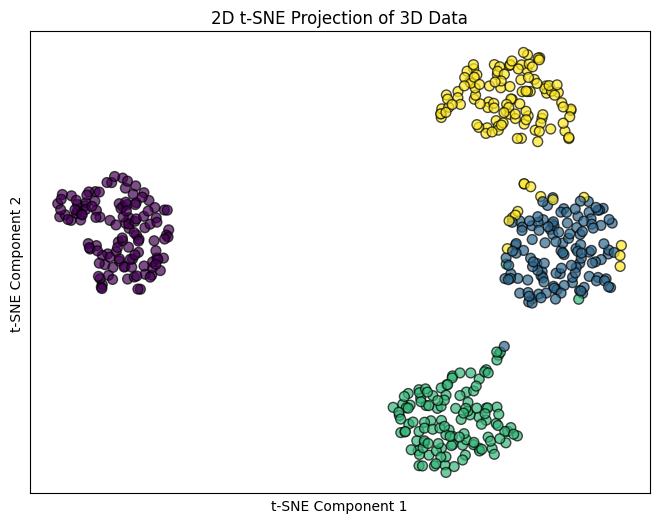

In [55]:
# Plot the 2D t-SNE result
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_, cmap='viridis',
           s=50, alpha=0.7, edgecolor='k')
ax.set_title("2D t-SNE Projection of 3D Data")
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

* t-SNE projected the data into four distinct clusters, although the original data had some overlap between a few clusters.
* We can see that some of the points ended up in the "wrong" cluster, although to be fair, t-SNE has no knowledge of which clusters the points actually belong to
* All the clusters have similar densities
* Two of the blobs are distinct from each other but "give up" some of their points to the blob they originally had overlapped with
* A "perfect" result would not completely separate the overlaps between blobs
* Notice that the distance between the blobs is consistent with the degree to which they were originally separated

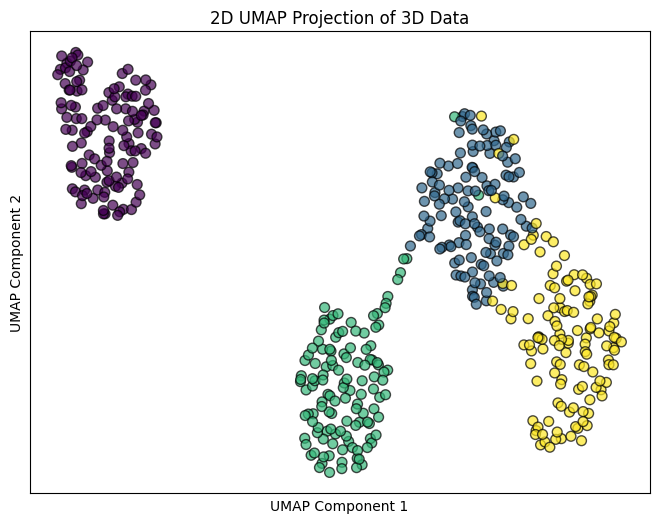

In [56]:
import umap.umap_ as UMAP

# Apply UMAP to reduce the dimensionality to 2D
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, 
                       spread=1, n_jobs=1)
X_umap = umap_model.fit_transform(X_scaled)

# Plot the 2D UMAP projection result
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_,
           cmap='viridis', s=50, alpha=0.7, edgecolor='k')

ax.set_title("2D UMAP Projection of 3D Data")
ax.set_xlabel("UMAP Component 1")
ax.set_ylabel("UMAP Component 2")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

* UMAP correctly projected the data into four partially distinct clusters, with one cluster completely distinct from the others.
* Unlike t-SNE, it has preserved the connectedness that the original data had with the partially overlapping clusters.
* We can see that, like t-SNE, some of the points ended up in the "wrong" cluster
* Again, like t-SNE, all the clusters have similar desities
* A "perfect" result would not completely seperate the overlaps between blobs, because they actually do overlap in the original feature space
* The distance between the clusters is again consistent with the degree to which they were originally separated

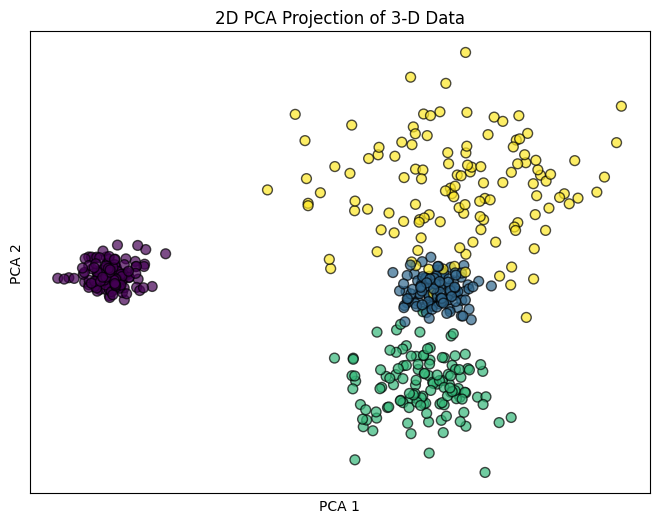

In [57]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(8,6))

# Plot the 2D PCA result (right)
ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("2D PCA Projection of 3-D Data")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()

* PCA faithfully preserved the relative blob densities
* PCA also preserved the relative separation between blobs
* The distance between the clusters is very consistent with the degree to which they were orignally separated
* PCA and t-SNE took very little time to complete compared to UMAP
* IMNSHO, PCA outperformed both t-SNE and UMAP in this experiment. This point to a common tendency to want to implement more advanced algorithms. The default result is not always an improvement over the simpler established method

---

## Test on Real Dataset

### About Dataset
Breast Cancer Wisconsin (Diagnostic)

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image. A few of the images can be found at http://www.cs.wisc.edu/~street/images/

Separating plane described above was obtained using Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree Construction Via Linear Programming." Proceedings of the 4th Midwest Artificial Intelligence and Cognitive Science Society, pp. 97-101, 1992], a classification method which uses linear programming to construct a decision tree.  Relevant features were selected using an exhaustive search in the space of 1-4 features and 1-3 separating planes.

The actual linear program used to obtain the separating plane in the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server:
ftp ftp.cs.wisc.edu
cd math-prog/cpo-dataset/machine-learn/WDBC/

In [58]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [59]:
pd.set_option("display.max_columns", None)
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


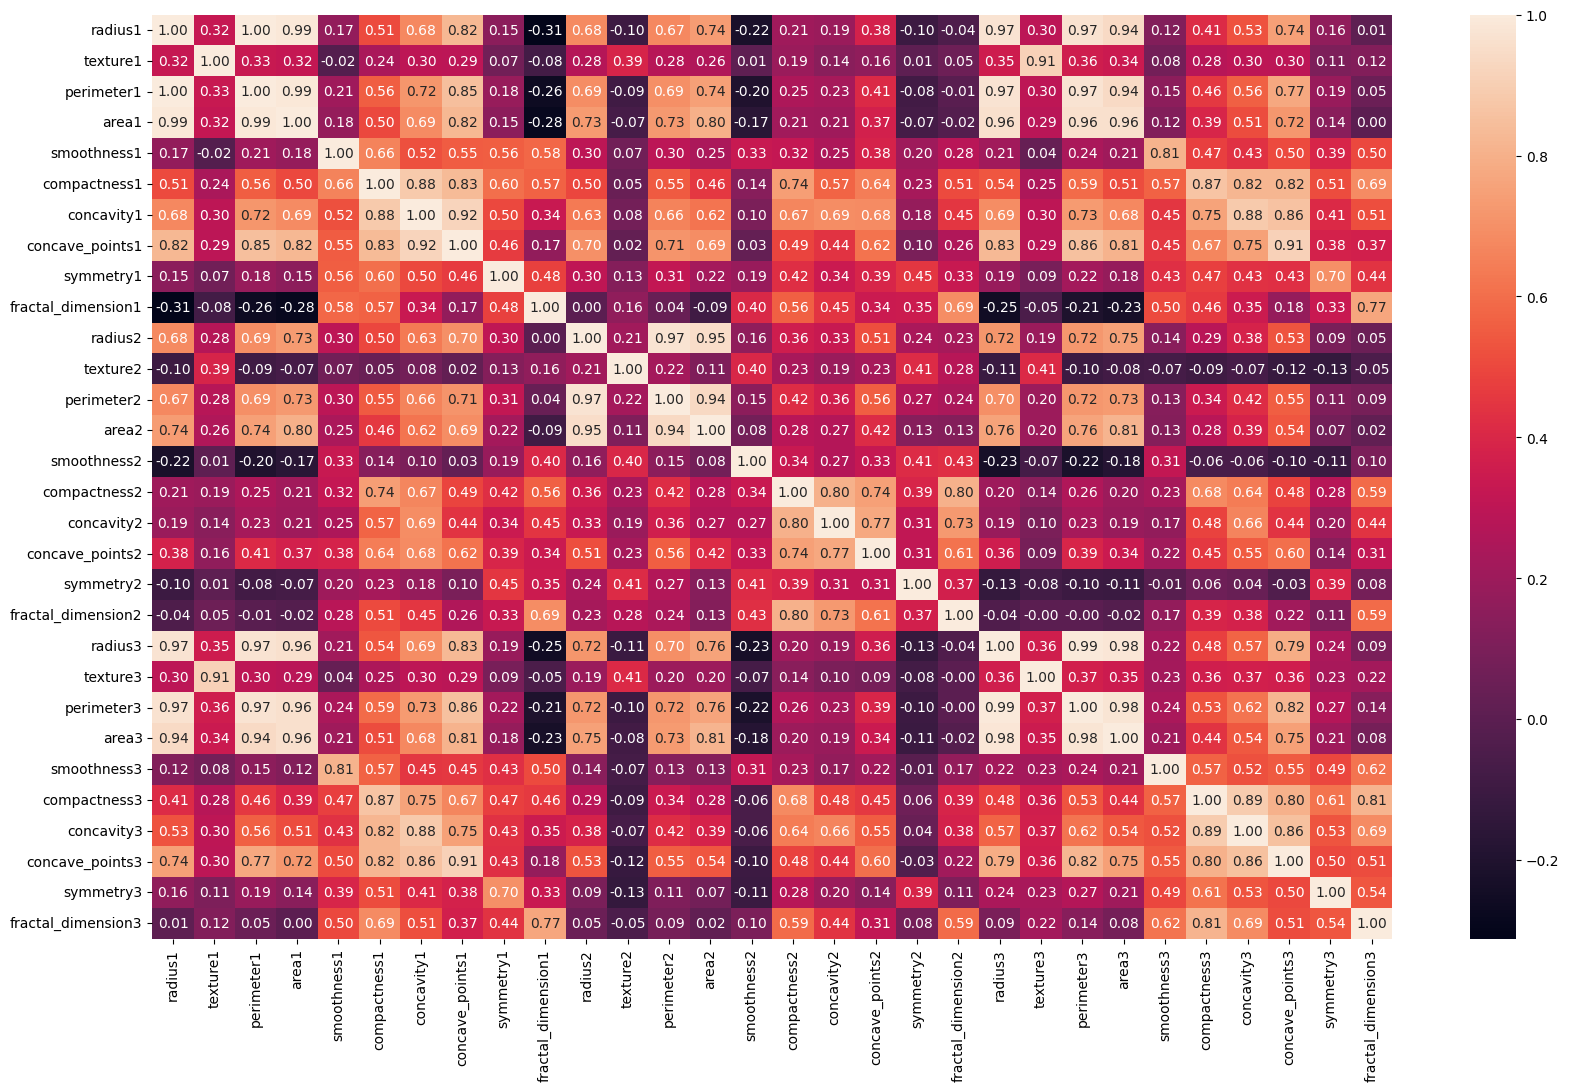

In [60]:
import seaborn as sns

# Check correlation
corr = X.corr()

plt.figure(figsize=(20,12))
sns.heatmap(data=corr, annot=True, fmt='.2f')
plt.show()

In [61]:
X.columns

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='object')

In [62]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap.umap_ import UMAP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Get Labels
y_labels = y.values.ravel()

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

# UMAP
umap = UMAP(n_neighbors=20, random_state=42, min_dist=0.1, spread=1, n_jobs=-1)
X_umap = umap.fit_transform(X_scaled)

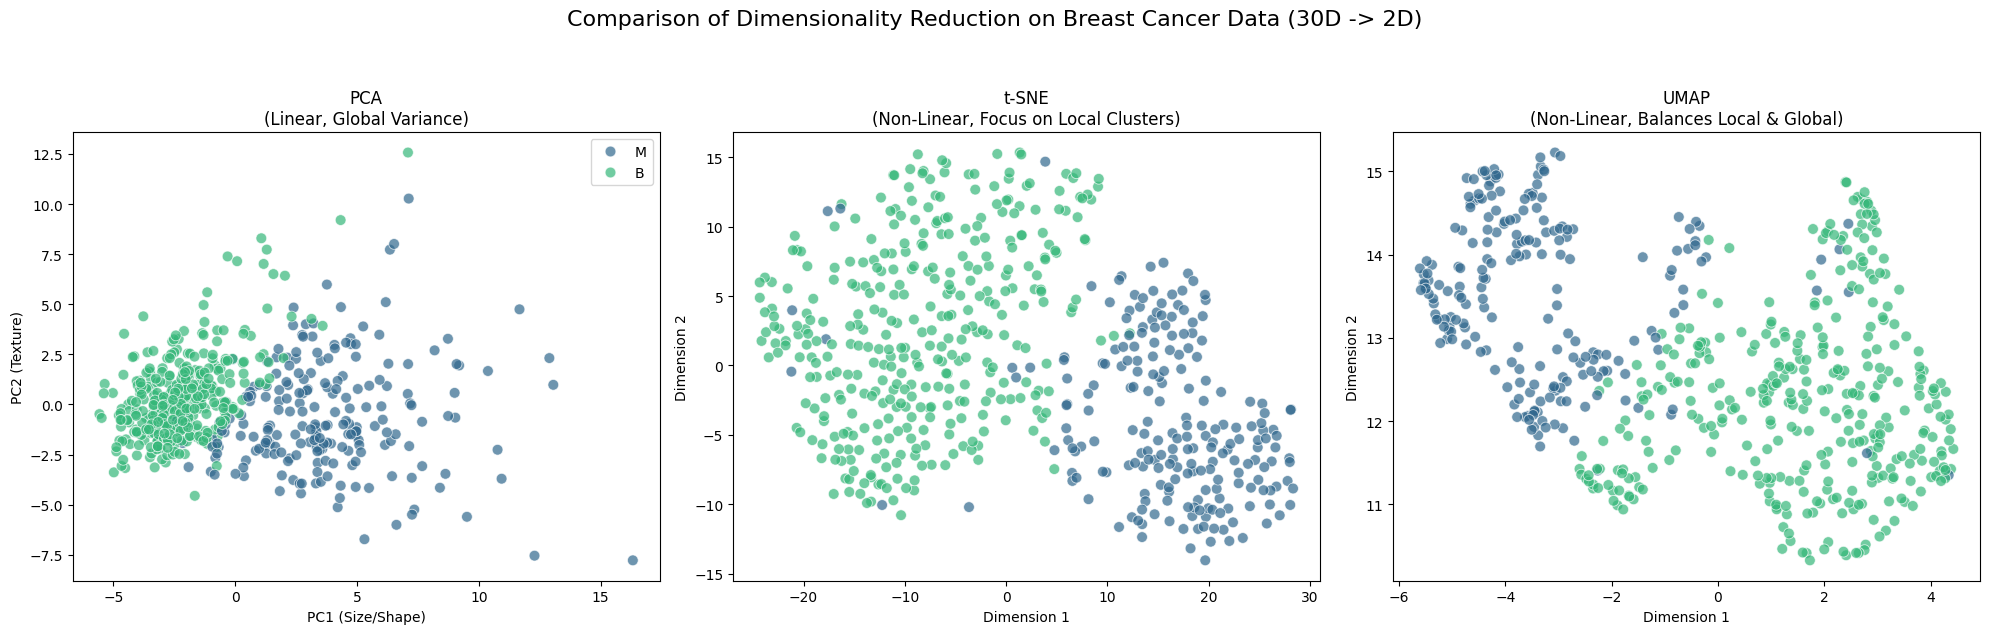

In [63]:
# --- 3. The Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Shared plotting parameters
scatter_kwargs = {'hue': y_labels, 'palette': 'viridis', 's': 60, 'alpha': 0.7, 'legend': 'full'}

# Plot 1: PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], ax=axes[0], **scatter_kwargs)
axes[0].set_title("PCA\n(Linear, Global Variance)")
axes[0].set_xlabel("PC1 (Size/Shape)")
axes[0].set_ylabel("PC2 (Texture)")

# Plot 2: t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], ax=axes[1], **scatter_kwargs)
axes[1].set_title("t-SNE\n(Non-Linear, Focus on Local Clusters)")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")
# Remove legend here to avoid clutter
axes[1].get_legend().remove()

# Plot 3: UMAP
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], ax=axes[2], **scatter_kwargs)
axes[2].set_title("UMAP\n(Non-Linear, Balances Local & Global)")
axes[2].set_xlabel("Dimension 1")
axes[2].set_ylabel("Dimension 2")
axes[2].get_legend().remove()

plt.suptitle("Comparison of Dimensionality Reduction on Breast Cancer Data (30D -> 2D)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

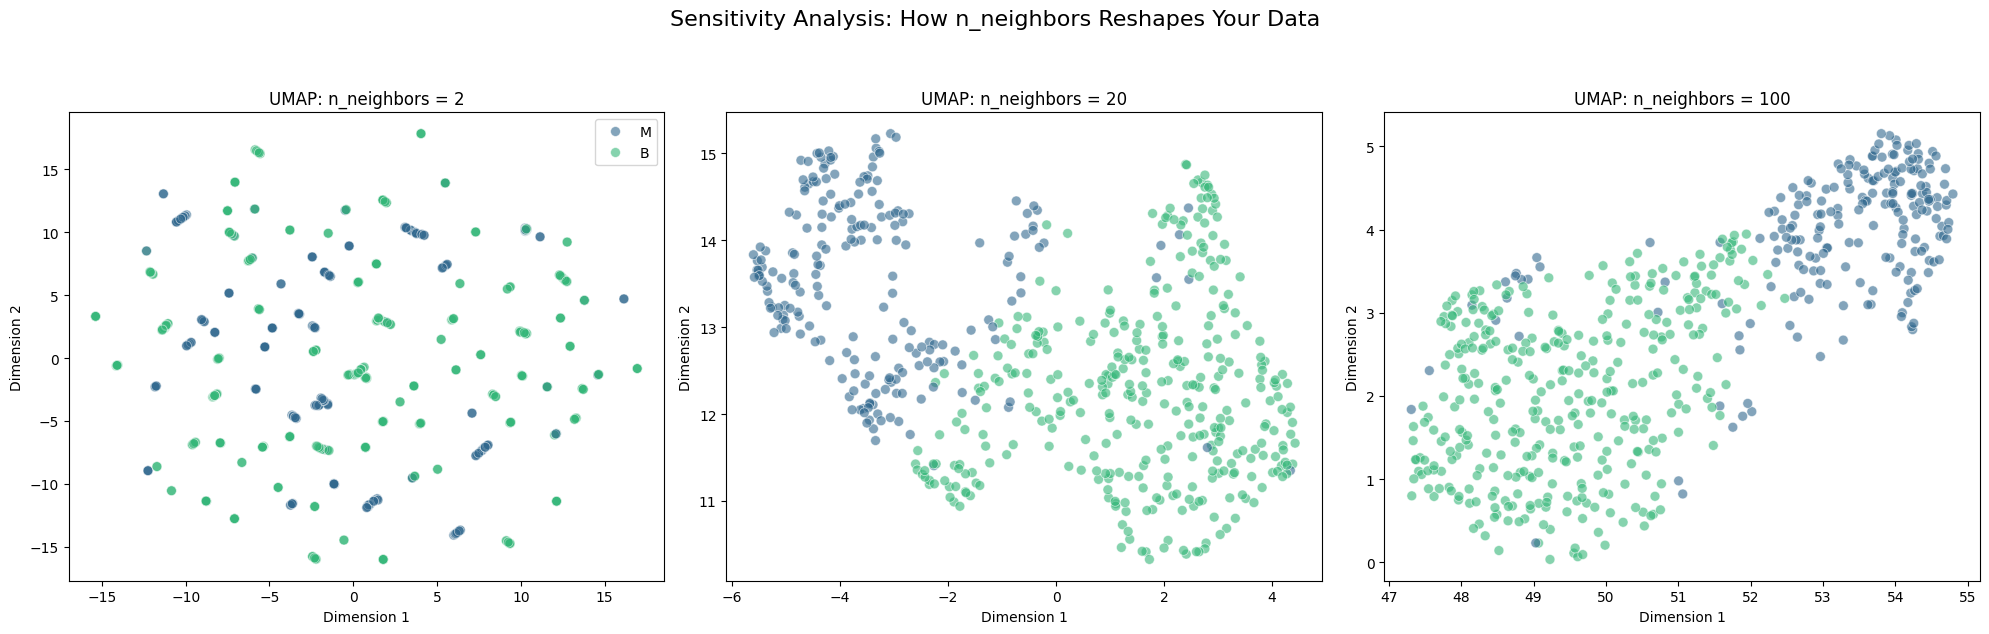

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# Values to test
neighbors_list = [2, 20, 100]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, k in enumerate(neighbors_list):
    # Fit UMAP with the specific n_neighbors value
    reducer = umap.UMAP(n_neighbors=k, min_dist=0.1, random_state=42, n_jobs=-1)
    embedding = reducer.fit_transform(X_scaled)
    
    # Plotting
    sns.scatterplot(
        x=embedding[:, 0], y=embedding[:, 1], 
        hue=y.values.ravel(), palette='viridis', 
        s=50, alpha=0.6, ax=axes[i], legend=(i == 0)
    )
    axes[i].set_title(f"UMAP: n_neighbors = {k}")
    axes[i].set_xlabel("Dimension 1")
    axes[i].set_ylabel("Dimension 2")

plt.suptitle("Sensitivity Analysis: How n_neighbors Reshapes Your Data", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

---

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

# Define pipeline
clf_pipeline = Pipeline([
    ('Scaler', StandardScaler()),
    ('dim_red', PCA(n_components=5)),
    ('classifier', RandomForestClassifier(n_jobs=-1, random_state=42, n_estimators=))
])

# fit the pipeline
clf_pipeline.fit(X_train, y_train)

# Predict
predictions = clf_pipeline.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Param grid
param_grid = {
    'dim_red__n_components': [2, 5, 10, 15, 30],
    'classifier__n_estimators': [50, 100, 200]
}

grid_search = GridSearchCV(clf_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


print(f"Best Number of PCA Components: {grid_search.best_params_['dim_red__n_components']}")
print(f"Best Number of Estimators: {grid_search.best_params_['classifier__n_estimators']}")
print(f"Best Accuracy: {grid_search.best_score_:.4f}")

Best Number of PCA Components: 5
Best Number of Estimators: 100
Best Accuracy: 0.9670


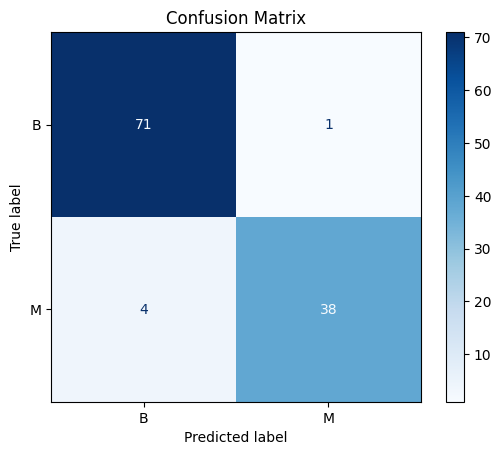

In [73]:
# Get the best estimator
best_pipeline = grid_search.best_estimator_

# Predict
y_pred = best_pipeline.predict(X_test)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [75]:
from sklearn.metrics import classification_report

# Generate the report
report = classification_report(y_test, y_pred, target_names=best_pipeline.classes_)

print("Final Model Report Card:")
print(report)

Final Model Report Card:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [90]:
from sklearn.metrics import precision_recall_curve

# Get probability
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Calculate precision, recall, and thresholds
y_test_binary = (y_test == 'M').astype(int)
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_proba)

# Find the best index
best_idx = np.where(recalls >= 1.0)[0][-1]

best_threshold = thresholds[best_idx]
print(f"Optimal Threshold for 100% Recall: {best_threshold:.4f}")

Optimal Threshold for 100% Recall: 0.1500


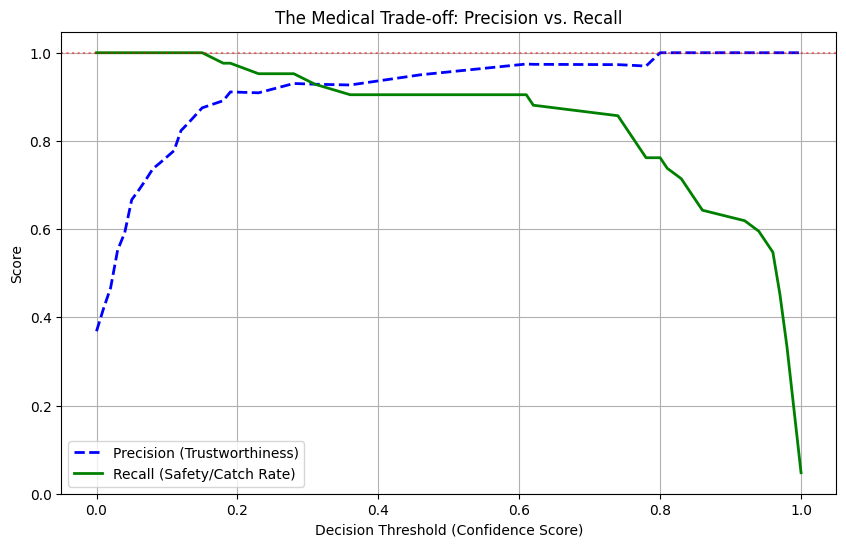

In [91]:
# 2. Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (Trustworthiness)", lw=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Safety/Catch Rate)", lw=2)

# 3. Styling the 'Clinical Zone'
plt.axhline(y=1.0, color='r', linestyle=':', alpha=0.5) # The 100% Goal
plt.xlabel("Decision Threshold (Confidence Score)")
plt.ylabel("Score")
plt.title("The Medical Trade-off: Precision vs. Recall")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

In [96]:
# Define the best threshold
custom_threshold = 0.15 

# Get the probability for the 'M' class
y_probs = best_pipeline.predict_proba(X_test)[:, 1]

# Apply the threshold to get new labels
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# 4. Map the 0s and 1s back to 'B' and 'M'
y_pred_final = np.where(y_pred_custom == 1, 'M', 'B')

# report
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           B       1.00      0.92      0.96        72
           M       0.88      1.00      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.96      0.94       114
weighted avg       0.95      0.95      0.95       114



In [103]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class ThresholdWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold
        self.classes_ = model.classes_

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        # index 1 = 'M', index 0 = 'B'
        probs = self.model.predict_proba(X)[:, 1]
        return np.where(probs >= self.threshold, self.classes_[1], self.classes_[0])

    def predict_proba(self, X):
        return self.model.predict_proba(X)

# Usage:
final_safe_model = ThresholdWrapper(best_pipeline, threshold=0.15)